# 07 · Picking a Reasoning Model for an Application

**Task:** answering questions about a folder of documents — using *retrieval as a tool* that a reasoning agent calls on its own.

This notebook is a small, runnable **model bake-off**. We give the same job to several frontier reasoning models, let each one drive a `search_notes` tool over a folder of ~26 notes, score the answers, and plot the results so you can pick a model with evidence instead of vibes.

**Candidates**

| Key | Model | API style |
|---|---|---|
| `gpt-5.5` | GPT-5.5 | OpenAI **Responses API** (`reasoning.effort`) |
| `claude-opus-4.8` | Claude Opus 4.8 | Anthropic **Messages** (adaptive thinking) |
| `gemini-3.1-pro` | Gemini 3.1 Pro | Google **google-genai** (manual function calling) |
| `deepseek-v4-pro` | DeepSeek V4 Pro | OpenAI-**compatible** chat completions |
| `glm-5.2` | GLM-5.2 (Zhipu) | OpenAI-**compatible** chat completions |

**Metrics:** `accuracy`, `latency`, `faithfulness`, `relevancy`.

> **Design choices that keep this cheap & simple**
> - Tiny eval set: **10 questions** over **26 short notes**.
> - Retrieval is a **local TF-IDF tool** (no embedding API, no vector DB) exposed as a function the agent calls — *RAG-as-a-tool*, not a full pipeline.
> - Reasoning effort / thinking budgets are kept **low**.
> - Any provider whose API key is missing is **skipped automatically**, so you can run with whatever keys you have.

## 0 · Setup

```bash
uv pip install openai anthropic google-genai scikit-learn pandas matplotlib python-dotenv
```

Put your keys in a `.env` file (only the ones you have — the rest are skipped):

```
OPENAI_API_KEY=...
ANTHROPIC_API_KEY=...
GEMINI_API_KEY=...
DEEPSEEK_API_KEY=...        # optional
GLM_API_KEY=...             # optional (or ZHIPUAI_API_KEY)
```

In [1]:
import os, json, time, textwrap
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv()

def have(*names):
    """Return the first non-empty env var among names (or None)."""
    for n in names:
        v = os.environ.get(n)
        if v:
            return v
    return None

print("Keys detected:")
for label, names in [
    ("OpenAI",   ["OPENAI_API_KEY"]),
    ("Anthropic",["ANTHROPIC_API_KEY"]),
    ("Gemini",   ["GEMINI_API_KEY", "GOOGLE_API_KEY"]),
    ("DeepSeek", ["DEEPSEEK_API_KEY"]),
    ("GLM/Zhipu",["GLM_API_KEY", "ZHIPUAI_API_KEY"]),
]:
    print(f"  {label:10s}: {'set' if have(*names) else '— missing (will skip)'}")

Keys detected:
  OpenAI    : set
  Anthropic : set
  Gemini    : set
  DeepSeek  : — missing (will skip)
  GLM/Zhipu : — missing (will skip)


## 1 · The task and the candidate registry

One registry describes every candidate: which API style it uses, the exact model id, and which env var holds its key. A model is **active** only if its key is present.

In [2]:
task_definition = "Answer questions about a folder of personal notes (reasoning-models knowledge base)."

eval_metrics = ["accuracy", "latency", "faithfulness", "relevancy"]

MODELS = {
    "gpt-5.5": {
        "label": "GPT-5.5",
        "kind": "openai_responses",
        "model_id": "gpt-5.5",
        "keys": ["OPENAI_API_KEY"],
    },
    "claude-opus-4.8": {
        "label": "Claude Opus 4.8",
        "kind": "anthropic",
        "model_id": "claude-opus-4-8",
        "keys": ["ANTHROPIC_API_KEY"],
    },
    "gemini-3.1-pro": {
        "label": "Gemini 3.1 Pro",
        "kind": "gemini",
        "model_id": "gemini-3.1-pro-preview",
        "keys": ["GEMINI_API_KEY", "GOOGLE_API_KEY"],
    },
    "deepseek-v4-pro": {
        "label": "DeepSeek V4 Pro",
        "kind": "chat",                       # OpenAI-compatible
        "model_id": "deepseek-v4-pro",
        "base_url": "https://api.deepseek.com",
        "keys": ["DEEPSEEK_API_KEY"],
    },
    "glm-5.2": {
        "label": "GLM-5.2",
        "kind": "chat",                       # OpenAI-compatible
        "model_id": "glm-5.2",
        "base_url": "https://open.bigmodel.cn/api/paas/v4/",
        "keys": ["GLM_API_KEY", "ZHIPUAI_API_KEY"],
    },
}

ACTIVE = [k for k, s in MODELS.items() if have(*s["keys"])]
print("Active models for this run:", ACTIVE or "(none — add at least one API key)")

Active models for this run: ['gpt-5.5', 'claude-opus-4.8', 'gemini-3.1-pro']


## 2 · The document corpus

A folder of 26 short markdown notes (a slice of a personal Obsidian vault on reasoning models, GRPO, distillation, prompting, etc.). This is the "documents in a folder" the agent must answer from.

In [3]:
NOTES_DIR = Path("notes_dataset")

note_paths  = sorted(NOTES_DIR.glob("*.md"))
note_titles = [p.stem for p in note_paths]
note_texts  = [p.read_text(encoding="utf-8") for p in note_paths]

print(f"Loaded {len(note_paths)} notes from {NOTES_DIR}/\n")
for t in note_titles:
    print(" •", t)

Loaded 26 notes from notes_dataset/

 • 12 Factors for building agents
 • 3 Reasons for langchain
 • 4 Anki card patterns - Extractive Explorative Subjective Active
 • Advanced Prompt Engineering Concepts and Patterns
 • Agentic Workflows
 • Code as Reasoning in LLMs in practice is
 • DAPO and Dr. GRPO
 • DeepSeek R1 training pipeline
 • DeepSeek R1-Zero
 • Emergent Abilities of LLMs
 • GRPO advantage refinements
 • GRPO length-normalization bias
 • GRPO vs PPO
 • GRPO
 • GSM-Symbolic Understanding the Limitations of Mathematical Reasoning in Large Language Models
 • Introduction to Fine Tuning
 • KL regularization in RL fine-tuning
 • Knowledge Distillation in LLMs
 • chain-of-thought as test-time compute
 • chain-of-thought prompting tips
 • code as reasoning
 • controlling the thinking budget
 • difference between RL and supervised learning
 • distilling reasoning into smaller models
 • format and accuracy rewards
 • how to prompt reasoning models - o1


## 3 · Retrieval as a **tool** (TF-IDF)

Instead of building a full RAG pipeline, we expose retrieval as a single function, `search_notes(query)`. The **agent decides** when and what to search. We use TF-IDF cosine similarity over whole notes — zero API cost, fully local, good enough for 26 short docs.

The same JSON parameter schema is reused across all five APIs (each just wraps it slightly differently).

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

_vectorizer = TfidfVectorizer(stop_words="english")
_matrix = _vectorizer.fit_transform(note_texts)

def search_notes(query: str, k: int = 3) -> str:
    """Return the top-k most relevant notes for a query, as one string."""
    qv = _vectorizer.transform([query])
    sims = cosine_similarity(qv, _matrix)[0]
    top = sims.argsort()[::-1][:k]
    blocks = []
    for i in top:
        body = note_texts[i].strip()
        blocks.append(f"### {note_titles[i]}\n{body}")
    return "\n\n---\n\n".join(blocks)

# Shared tool spec (plain JSON Schema for the parameters)
TOOL_NAME = "search_notes"
TOOL_DESC = ("Search the personal notes knowledge base and return the most "
             "relevant notes. Call this before answering.")
TOOL_PARAMS = {
    "type": "object",
    "properties": {
        "query": {"type": "string",
                  "description": "Keywords or a question to find relevant notes."}
    },
    "required": ["query"],
}

# quick sanity check
print(search_notes("How is the GRPO advantage computed vs PPO?")[:600], "...")

### GRPO vs PPO
# GRPO vs PPO

Both optimize the same clipped policy-ratio objective with a KL leash; they differ in **how the advantage is estimated** and **what extra model must be trained**.

**Similarities:** both use the new/old policy ratio `ρ = π_θ/π_θold` and a `clip(ρ, 1−ε, 1+ε)` mechanism to keep updates small.

**Differences:**

| | PPO | GRPO |
|---|---|---|
| Advantage | from a **Value Model** + GAE (generalized advantage estimation), per-token | **group-relative**: reward − group mean (÷ std), shared across all tokens of an output |
| Value/critic network | **trained** (extra cos ...


## 4 · The evaluation set (10 questions)

Ten questions, each with a short reference answer grounded in the notes. These are what we grade the models against.

In [5]:
TASKS = [
    {"id": "q01",
     "question": "In GRPO, how is the advantage for each completion computed, and which network does it eliminate compared to PPO?",
     "reference": "Advantage is group-relative: (reward - group mean) / group std, scored against a sampled group of completions. It eliminates the value/critic network that PPO must train."},
    {"id": "q02",
     "question": "What are DAPO and Dr. GRPO, and what GRPO problem do they fix?",
     "reference": "Both fix the GRPO length-normalization bias (the 1/|o_i| per-output factor that makes the model prefer longer bad outputs). DAPO normalizes once over total tokens in the group (and adds clip-higher); Dr. GRPO drops the length factor entirely. Result: incorrect-answer length stops ballooning."},
    {"id": "q03",
     "question": "How many stages are in the DeepSeek R1 training pipeline, and what is stage 2?",
     "reference": "Five stages. Stage 2 is small-scale cold-start SFT: a few thousand long chains-of-thought from R1-Zero, rewritten by humans for clean formatting and language consistency, used as an anchor before RL."},
    {"id": "q04",
     "question": "What reward does DeepSeek R1-Zero use, and what delimiters does its prompt template require?",
     "reference": "A verifiable format + accuracy reward (no learned reward model). The template instructs the model to put reasoning in <think></think> and the final result in <answer></answer>."},
    {"id": "q05",
     "question": "What two intuitions explain why chain-of-thought helps?",
     "reference": "(1) Decomposition: breaking a hard problem into sub-problems lets the model reuse patterns it has seen. (2) More compute: each generated token is another forward pass, so emitting more reasoning tokens buys more computation before answering (test-time scaling)."},
    {"id": "q06",
     "question": "Name two techniques for controlling a reasoning model's thinking budget.",
     "reference": "Any two of: dynamic budget (a classifier tags prompts high/low thinking), context awareness, budget forcing ('Wait' to extend, 'time is up' to stop), or continuous/latent thoughts (Coconut)."},
    {"id": "q07",
     "question": "According to the o1 prompting guidance, should you tell a reasoning model to 'think step by step', and what replaces system messages?",
     "reference": "No — avoid chain-of-thought prompts like 'think step by step'; it is unnecessary and can hurt. Developer messages replace system messages for these models."},
    {"id": "q08",
     "question": "What does the GSM-Symbolic study conclude about LLM math reasoning, including the effect of irrelevant information?",
     "reference": "LLM reasoning is fragile and looks like pattern-matching: performance varies with numeric changes and drops as logical clauses increase. Adding irrelevant information (GSM-NoOp) causes performance drops of up to 65%."},
    {"id": "q09",
     "question": "In reasoning distillation (R1-Distill), is the student trained by logit matching or plain SFT, and how does it compare to RL-from-scratch at small scale?",
     "reference": "Plain SFT on the teacher's generated reasoning traces (including <think> traces), not logit matching. At small scale, distillation beats RL-from-scratch — e.g. same Qwen-32B base: RL gives AIME 47.0 but distilling from R1 gives 72.6."},
    {"id": "q10",
     "question": "What does the KL penalty enforce in RL fine-tuning, and how do PPO and GRPO differ in where the KL term lives?",
     "reference": "It keeps the policy from drifting too far from a trusted reference (usually the SFT/reference model). PPO folds the KL into the reward per-token before advantage estimation; GRPO uses a separate explicit -beta*KL term in the objective."},
]

print(f"{len(TASKS)} evaluation tasks ready.")

10 evaluation tasks ready.


## 5 · Provider adapters (one agent loop per API)

Each adapter runs the same loop: send the question + the `search_notes` tool, execute any tool calls the model makes, feed results back, and return the final answer plus latency and tool-call count. The APIs differ in mechanics, so we keep one small function per style and a single `run_agent` dispatcher.

In [6]:
# Build clients only for active providers ------------------------------------
CLIENTS = {}

if have("OPENAI_API_KEY"):
    from openai import OpenAI
    _openai = OpenAI()
else:
    _openai = None

for key in ACTIVE:
    spec = MODELS[key]
    kind = spec["kind"]
    if kind == "openai_responses":
        CLIENTS[key] = _openai
    elif kind == "anthropic":
        from anthropic import Anthropic
        CLIENTS[key] = Anthropic()
    elif kind == "gemini":
        from google import genai
        CLIENTS[key] = genai.Client(api_key=have("GEMINI_API_KEY", "GOOGLE_API_KEY"))
    elif kind == "chat":
        from openai import OpenAI
        CLIENTS[key] = OpenAI(api_key=have(*spec["keys"]), base_url=spec["base_url"])

print("Built clients for:", list(CLIENTS))

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


Built clients for: ['gpt-5.5', 'claude-opus-4.8', 'gemini-3.1-pro']


In [8]:
SYSTEM_PROMPT = (
    "You are a research assistant that answers questions strictly from a personal "
    "notes knowledge base about reasoning models and LLM training. You have a tool "
    "`search_notes(query)` that returns the most relevant notes. Always call "
    "`search_notes` at least once before answering. Base your answer ONLY on the "
    "retrieved notes; if they do not contain the answer, say so. Answer in 2-4 "
    "concise sentences."
)
MAX_ITERS = 4  # tool-call rounds before we stop


# --- OpenAI Responses API (gpt-5.5) -----------------------------------------
def run_openai(client, model_id, question):
    tool = {"type": "function", "name": TOOL_NAME,
            "description": TOOL_DESC, "parameters": TOOL_PARAMS}
    t0 = time.perf_counter(); n = 0
    resp = client.responses.create(
        model=model_id, reasoning={"effort": "low"}, tools=[tool],
        instructions=SYSTEM_PROMPT,
        input=[{"role": "user", "content": question}],
    )
    for _ in range(MAX_ITERS):
        calls = [i for i in resp.output if i.type == "function_call"]
        if not calls:
            break
        outs = []
        for fc in calls:
            n += 1
            result = search_notes(**json.loads(fc.arguments))
            outs.append({"type": "function_call_output",
                         "call_id": fc.call_id, "output": result})
        resp = client.responses.create(
            model=model_id, reasoning={"effort": "low"}, tools=[tool],
            input=outs, previous_response_id=resp.id,
        )
    return {"answer": resp.output_text or "", "latency_s": time.perf_counter() - t0,
            "n_tool_calls": n, "error": None}


# --- Anthropic Messages API (extended thinking) -----------------------------
def run_anthropic(client, model_id, question):
    tool = {"name": TOOL_NAME, "description": TOOL_DESC, "input_schema": TOOL_PARAMS}
    t0 = time.perf_counter(); n = 0
    msgs = [{"role": "user", "content": question}]
    for _ in range(MAX_ITERS + 1):
        resp = client.messages.create(
            model=model_id, max_tokens=3000,
            thinking={"type": "adaptive"}, output_config={"effort": "low"},
            system=SYSTEM_PROMPT, tools=[tool], messages=msgs,
        )
        tool_uses = [b for b in resp.content if b.type == "tool_use"]
        if not tool_uses:
            text = "".join(b.text for b in resp.content if b.type == "text")
            return {"answer": text, "latency_s": time.perf_counter() - t0,
                    "n_tool_calls": n, "error": None}
        msgs.append({"role": "assistant", "content": resp.content})
        results = []
        for tu in tool_uses:
            n += 1
            results.append({"type": "tool_result", "tool_use_id": tu.id,
                            "content": search_notes(**tu.input)})
        msgs.append({"role": "user", "content": results})
    return {"answer": "", "latency_s": time.perf_counter() - t0,
            "n_tool_calls": n, "error": "max iterations"}


# --- Google Gemini (google-genai, manual function calling) ------------------
def run_gemini(client, model_id, question):
    from google.genai import types
    tool = types.Tool(function_declarations=[types.FunctionDeclaration(
        name=TOOL_NAME, description=TOOL_DESC, parameters_json_schema=TOOL_PARAMS)])
    cfg = types.GenerateContentConfig(
        tools=[tool], system_instruction=SYSTEM_PROMPT,
        automatic_function_calling=types.AutomaticFunctionCallingConfig(disable=True),
    )
    t0 = time.perf_counter(); n = 0
    contents = [types.Content(role="user", parts=[types.Part(text=question)])]
    for _ in range(MAX_ITERS + 1):
        resp = client.models.generate_content(model=model_id, contents=contents, config=cfg)
        calls = resp.function_calls or []
        if not calls:
            return {"answer": resp.text or "", "latency_s": time.perf_counter() - t0,
                    "n_tool_calls": n, "error": None}
        contents.append(resp.candidates[0].content)
        for fc in calls:
            n += 1
            result = search_notes(**dict(fc.args))
            contents.append(types.Content(role="tool", parts=[
                types.Part.from_function_response(name=fc.name, response={"result": result})]))
    return {"answer": "", "latency_s": time.perf_counter() - t0,
            "n_tool_calls": n, "error": "max iterations"}


# --- OpenAI-compatible Chat Completions (DeepSeek, GLM) ---------------------
def run_chat(client, model_id, question):
    tool = {"type": "function", "function": {
        "name": TOOL_NAME, "description": TOOL_DESC, "parameters": TOOL_PARAMS}}
    t0 = time.perf_counter(); n = 0
    msgs = [{"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": question}]
    for _ in range(MAX_ITERS + 1):
        resp = client.chat.completions.create(
            model=model_id, messages=msgs, tools=[tool], tool_choice="auto")
        m = resp.choices[0].message
        if not m.tool_calls:
            return {"answer": m.content or "", "latency_s": time.perf_counter() - t0,
                    "n_tool_calls": n, "error": None}
        msgs.append(m)
        for tc in m.tool_calls:
            n += 1
            result = search_notes(**json.loads(tc.function.arguments))
            msgs.append({"role": "tool", "tool_call_id": tc.id, "content": result})
    return {"answer": "", "latency_s": time.perf_counter() - t0,
            "n_tool_calls": n, "error": "max iterations"}


_DISPATCH = {"openai_responses": run_openai, "anthropic": run_anthropic,
             "gemini": run_gemini, "chat": run_chat}

def run_agent(model_key, question):
    spec = MODELS[model_key]
    try:
        return _DISPATCH[spec["kind"]](CLIENTS[model_key], spec["model_id"], question)
    except Exception as e:
        return {"answer": "", "latency_s": None, "n_tool_calls": 0,
                "error": f"{type(e).__name__}: {e}"[:300]}

print("Adapters ready.")

Adapters ready.


## 6 · Smoke test

Run **one** question on the first active model to confirm everything is wired up before spending on the full sweep.

In [9]:
if ACTIVE:
    demo_key = ACTIVE[0]
    print(f"Model: {MODELS[demo_key]['label']}\nQ: {TASKS[0]['question']}\n" + "-" * 60)
    out = run_agent(demo_key, TASKS[0]["question"])
    print("Answer:   ", out["answer"])
    print("Latency:  ", None if out["latency_s"] is None else f"{out['latency_s']:.1f}s")
    print("Tool calls:", out["n_tool_calls"])
    print("Error:    ", out["error"])
else:
    print("No active models — add an API key and re-run.")

Model: GPT-5.5
Q: In GRPO, how is the advantage for each completion computed, and which network does it eliminate compared to PPO?
------------------------------------------------------------
Answer:    In **GRPO**, for a given prompt/query, you sample a **group** of completions and score each one with a reward. The advantage for completion \(i\) is computed relative to the rewards of the other completions in the same group:

\[
\hat A_i = \frac{R_i - \text{mean}(R_1,\dots,R_G)}{\text{std}(R_1,\dots,R_G)}
\]

Sometimes it is described simply as:

\[
\hat A_i = R_i - \text{group mean reward}
\]

So a completion gets positive advantage if it scores above the group average, and negative advantage if it scores below.

Compared to **PPO**, GRPO eliminates the learned **value network / critic**. PPO typically trains a separate value model to estimate advantages, while GRPO uses the group-relative reward baseline instead.
Latency:   8.5s
Tool calls: 1
Error:     None


## 7 · LLM-as-judge

A judge model scores each answer against the reference and the retrieved notes on three axes:
- **accuracy** — 0/1, does it match the reference?
- **faithfulness** — 1-5, is it grounded (not hallucinated)?
- **relevancy** — 1-5, does it actually answer the question?

We use OpenAI as the judge if available, else Anthropic, else a simple keyword-overlap fallback so the notebook still runs with no judge key.

In [10]:
JUDGE_INSTRUCTIONS = (
    "You are a strict grader. Given a QUESTION, a REFERENCE answer, and a "
    "CANDIDATE answer, return ONLY a JSON object with keys: "
    "correct (0 or 1 — 1 only if the candidate captures the key facts of the "
    "reference), faithfulness (1-5 — grounded vs hallucinated), "
    "relevancy (1-5 — does it answer the question). No prose, JSON only."
)

def _judge_prompt(q, ref, ans):
    return (f"QUESTION:\n{q}\n\nREFERENCE:\n{ref}\n\n"
            f"CANDIDATE:\n{ans}\n\nReturn the JSON now.")

def _parse_json(text):
    text = text.strip()
    if "{" in text:
        text = text[text.index("{"): text.rindex("}") + 1]
    return json.loads(text)

def judge(question, reference, answer):
    if not answer or not answer.strip():
        return {"correct": 0, "faithfulness": 0.0, "relevancy": 0.0}
    prompt = _judge_prompt(question, reference, answer)
    try:
        if have("OPENAI_API_KEY"):
            r = _openai.responses.create(
                model="gpt-5.5", reasoning={"effort": "low"},
                instructions=JUDGE_INSTRUCTIONS,
                input=[{"role": "user", "content": prompt}])
            data = _parse_json(r.output_text)
        elif have("ANTHROPIC_API_KEY"):
            from anthropic import Anthropic
            r = Anthropic().messages.create(
                model="claude-opus-4-8", max_tokens=300,
                system=JUDGE_INSTRUCTIONS,
                messages=[{"role": "user", "content": prompt}])
            data = _parse_json("".join(b.text for b in r.content if b.type == "text"))
        else:
            raise RuntimeError("no judge key")
        return {"correct": int(data["correct"]),
                "faithfulness": float(data["faithfulness"]) / 5.0,
                "relevancy": float(data["relevancy"]) / 5.0}
    except Exception:
        # Fallback: keyword overlap with the reference
        ref_words = {w.lower().strip(".,()") for w in reference.split() if len(w) > 4}
        ans_words = {w.lower().strip(".,()") for w in answer.split()}
        overlap = len(ref_words & ans_words) / max(1, len(ref_words))
        return {"correct": int(overlap > 0.35),
                "faithfulness": round(min(1.0, overlap + 0.3), 2),
                "relevancy": round(min(1.0, overlap + 0.3), 2)}

print("Judge ready (judge =",
      "OpenAI" if have("OPENAI_API_KEY") else
      "Anthropic" if have("ANTHROPIC_API_KEY") else "keyword-fallback", ")")

Judge ready (judge = OpenAI )


## 8 · Run the evaluation

`active models × 10 questions`. Each cell prints progress; results land in a tidy DataFrame and a CSV.

In [11]:
rows = []
total = len(ACTIVE) * len(TASKS)
i = 0
for key in ACTIVE:
    label = MODELS[key]["label"]
    for task in TASKS:
        i += 1
        out = run_agent(key, task["question"])
        scores = judge(task["question"], task["reference"], out["answer"])
        rows.append({
            "model": label, "model_key": key, "qid": task["id"],
            "accuracy": scores["correct"],
            "faithfulness": scores["faithfulness"],
            "relevancy": scores["relevancy"],
            "latency_s": out["latency_s"],
            "n_tool_calls": out["n_tool_calls"],
            "error": out["error"],
            "answer": out["answer"],
        })
        flag = "OK " if not out["error"] else "ERR"
        lat = "  ?  " if out["latency_s"] is None else f"{out['latency_s']:5.1f}s"
        print(f"[{i:>2}/{total}] {flag} {label:16s} {task['id']} "
              f"acc={scores['correct']} {lat}")

results = pd.DataFrame(rows)
results.to_csv("model_bakeoff_results.csv", index=False)
print("\nSaved -> model_bakeoff_results.csv")
results[["model", "qid", "accuracy", "faithfulness", "relevancy", "latency_s"]].head(12)

[ 1/30] OK  GPT-5.5          q01 acc=1   5.8s
[ 2/30] OK  GPT-5.5          q02 acc=1  17.4s
[ 3/30] OK  GPT-5.5          q03 acc=1   5.9s
[ 4/30] OK  GPT-5.5          q04 acc=1  10.5s
[ 5/30] OK  GPT-5.5          q05 acc=1   4.2s
[ 6/30] OK  GPT-5.5          q06 acc=1   4.2s
[ 7/30] OK  GPT-5.5          q07 acc=1   5.4s
[ 8/30] OK  GPT-5.5          q08 acc=1   8.7s
[ 9/30] OK  GPT-5.5          q09 acc=1   7.1s
[10/30] OK  GPT-5.5          q10 acc=1   8.2s
[11/30] OK  Claude Opus 4.8  q01 acc=1   5.9s
[12/30] OK  Claude Opus 4.8  q02 acc=1   8.1s
[13/30] OK  Claude Opus 4.8  q03 acc=1   4.1s
[14/30] OK  Claude Opus 4.8  q04 acc=1   4.5s
[15/30] OK  Claude Opus 4.8  q05 acc=1   4.5s
[16/30] OK  Claude Opus 4.8  q06 acc=1  24.0s
[17/30] OK  Claude Opus 4.8  q07 acc=1  12.5s
[18/30] OK  Claude Opus 4.8  q08 acc=1   6.7s
[19/30] OK  Claude Opus 4.8  q09 acc=1   6.6s
[20/30] OK  Claude Opus 4.8  q10 acc=1   5.9s
[21/30] OK  Gemini 3.1 Pro   q01 acc=1   8.2s
[22/30] OK  Gemini 3.1 Pro   q02 a

,model,qid,accuracy,faithfulness,relevancy,latency_s
0,GPT-5.5,q01,1,1.0,1.0,5.824934
1,GPT-5.5,q02,1,1.0,1.0,17.398091
2,GPT-5.5,q03,1,1.0,1.0,5.949716
3,GPT-5.5,q04,1,1.0,1.0,10.529021
4,GPT-5.5,q05,1,1.0,1.0,4.165583
5,GPT-5.5,q06,1,1.0,1.0,4.208089
6,GPT-5.5,q07,1,1.0,1.0,5.438806
7,GPT-5.5,q08,1,1.0,1.0,8.679352
8,GPT-5.5,q09,1,1.0,1.0,7.100366
9,GPT-5.5,q10,1,1.0,1.0,8.199141


## 9 · Aggregate & leaderboard

Mean per model, plus a composite score (accuracy weighted highest).

In [12]:
agg = (results.groupby("model")
       .agg(accuracy=("accuracy", "mean"),
            faithfulness=("faithfulness", "mean"),
            relevancy=("relevancy", "mean"),
            latency_s=("latency_s", "mean"),
            tool_calls=("n_tool_calls", "mean"),
            errors=("error", lambda s: s.notna().sum()))
       .reset_index())

agg["score"] = 0.6 * agg["accuracy"] + 0.2 * agg["faithfulness"] + 0.2 * agg["relevancy"]
agg = agg.sort_values("score", ascending=False).reset_index(drop=True)

leaderboard = agg.round({"accuracy": 2, "faithfulness": 2, "relevancy": 2,
                         "latency_s": 1, "tool_calls": 1, "score": 3})
leaderboard

,model,accuracy,faithfulness,relevancy,latency_s,tool_calls,errors,score
0,Claude Opus 4.8,1.0,1.0,1.0,8.3,1.5,0,1.0
1,GPT-5.5,1.0,1.0,1.0,7.7,1.0,0,1.0
2,Gemini 3.1 Pro,1.0,1.0,1.0,8.7,1.0,0,1.0


## 10 · Visualizations

Four views to support a decision: quality breakdown, speed, the accuracy↔latency trade-off, and a per-question correctness map.

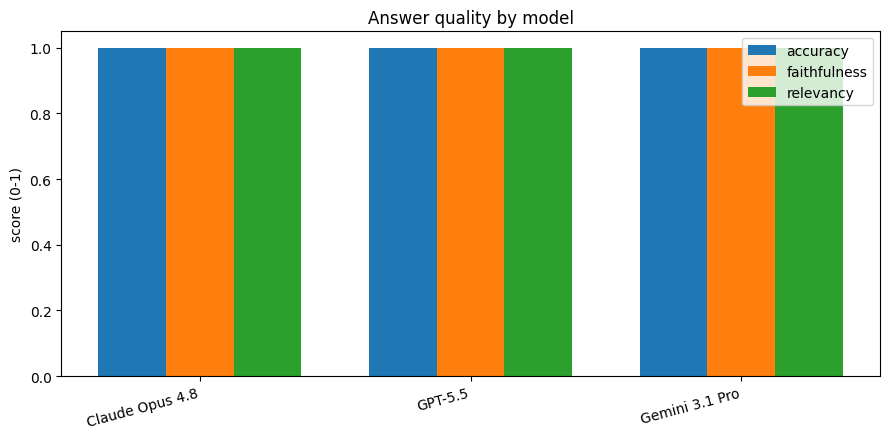

In [13]:
import numpy as np

plot_df = agg.set_index("model")
colors = plt.cm.tab10(np.linspace(0, 1, len(plot_df)))

# (1) Quality metrics grouped bar -------------------------------------------
metrics = ["accuracy", "faithfulness", "relevancy"]
x = np.arange(len(plot_df)); w = 0.25
fig, ax = plt.subplots(figsize=(9, 4.5))
for j, m in enumerate(metrics):
    ax.bar(x + (j - 1) * w, plot_df[m], w, label=m)
ax.set_xticks(x); ax.set_xticklabels(plot_df.index, rotation=15, ha="right")
ax.set_ylim(0, 1.05); ax.set_ylabel("score (0-1)")
ax.set_title("Answer quality by model"); ax.legend()
plt.tight_layout(); plt.show()

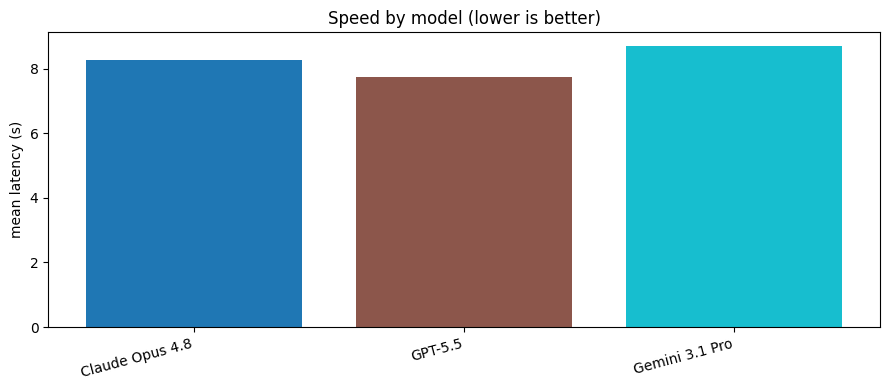

In [14]:
# (2) Latency bar ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(plot_df.index, plot_df["latency_s"], color=colors)
ax.set_ylabel("mean latency (s)")
ax.set_title("Speed by model (lower is better)")
ax.set_xticks(range(len(plot_df)))
ax.set_xticklabels(plot_df.index, rotation=15, ha="right")
plt.tight_layout(); plt.show()

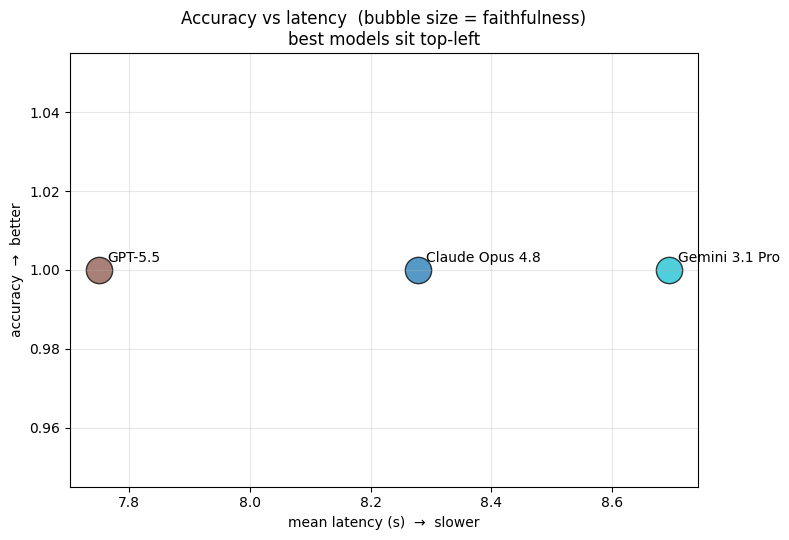

In [15]:
# (3) The decision plot: accuracy vs latency --------------------------------
fig, ax = plt.subplots(figsize=(8, 5.5))
for (name, row), c in zip(plot_df.iterrows(), colors):
    ax.scatter(row["latency_s"], row["accuracy"], s=300 * row["faithfulness"] + 60,
               color=c, alpha=0.75, edgecolors="black")
    ax.annotate(name, (row["latency_s"], row["accuracy"]),
                xytext=(6, 6), textcoords="offset points", fontsize=10)
ax.set_xlabel("mean latency (s)  →  slower")
ax.set_ylabel("accuracy  →  better")
ax.set_title("Accuracy vs latency  (bubble size = faithfulness)\nbest models sit top-left")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

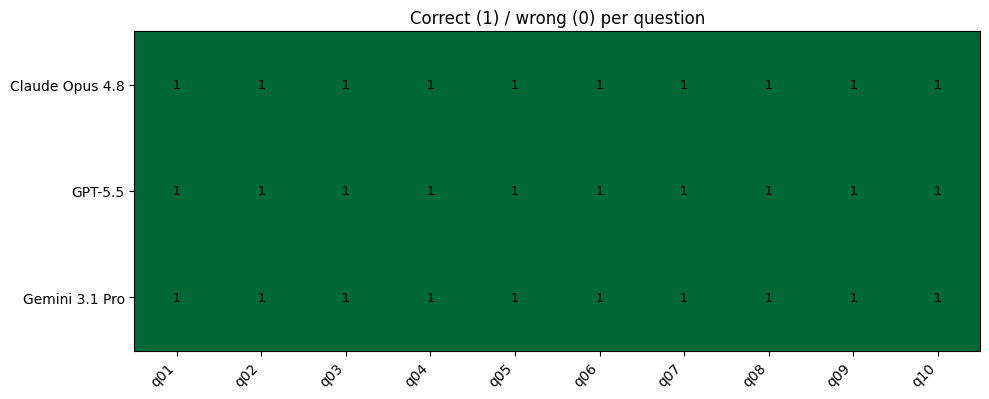

In [16]:
# (4) Per-question correctness heatmap --------------------------------------
pivot = results.pivot_table(index="model", columns="qid",
                            values="accuracy", aggfunc="mean")
fig, ax = plt.subplots(figsize=(10, 0.7 * len(pivot) + 2))
im = ax.imshow(pivot.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, rotation=45, ha="right")
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
for yi in range(pivot.shape[0]):
    for xi in range(pivot.shape[1]):
        v = pivot.values[yi, xi]
        ax.text(xi, yi, "" if np.isnan(v) else int(v), ha="center", va="center", fontsize=9)
ax.set_title("Correct (1) / wrong (0) per question")
plt.tight_layout(); plt.show()

## 11 · Pick a model

In [17]:
if len(agg):
    best = agg.iloc[0]
    fastest = agg.loc[agg["latency_s"].idxmin()]
    print(f"Top overall:  {best['model']}  "
          f"(score={best['score']:.3f}, acc={best['accuracy']:.0%}, "
          f"faith={best['faithfulness']:.2f}, {best['latency_s']:.1f}s)")
    print(f"Fastest:      {fastest['model']}  "
          f"({fastest['latency_s']:.1f}s, acc={fastest['accuracy']:.0%})")
    print()
    print("Rule of thumb for 'answer questions over a document folder':")
    print("  • Accuracy + faithfulness matter most → favor the top of the leaderboard.")
    print("  • If answers are close, pick the faster / cheaper model.")
    print("  • Watch the heatmap: a model that fails the SAME questions everyone fails")
    print("    points to a retrieval gap, not a model gap — improve the search tool.")
else:
    print("No results — add an API key and re-run section 8.")

Top overall:  Claude Opus 4.8  (score=1.000, acc=100%, faith=1.00, 8.3s)
Fastest:      GPT-5.5  (7.7s, acc=100%)

Rule of thumb for 'answer questions over a document folder':
  • Accuracy + faithfulness matter most → favor the top of the leaderboard.
  • If answers are close, pick the faster / cheaper model.
  • Watch the heatmap: a model that fails the SAME questions everyone fails
    points to a retrieval gap, not a model gap — improve the search tool.


### Recap

- We treated **retrieval as a tool** (`search_notes`) and let each reasoning model drive it — *RAG-as-a-tool*, not a hardwired pipeline.
- The same 10-question eval ran across **five APIs** (Responses, Messages, google-genai, and two OpenAI-compatible endpoints) behind one `run_agent` interface.
- We scored `accuracy / faithfulness / relevancy / latency` and visualized the trade-offs.

**To extend:** swap in your own folder under `notes_dataset/`, add more questions to `TASKS`, raise `reasoning.effort` / thinking budgets, or replace the TF-IDF tool with an embedding search — the adapters and scoring stay the same.